In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
import os

# df_Enamine_DR_growthCurves

In [2]:
df_Enamine_DR_growthCurves=pd.read_csv('/home/ethan2/GrowthNet/data/raw/Enamine_DR_growthcurves.csv')

df_Enamine_DR_growthCurves=df_Enamine_DR_growthCurves.rename(columns={"Plate":"Plate_ID"})
df_Enamine_DR_growthCurves['Control_Label'] = 0

df_Enamine_DR_growthCurves=df_Enamine_DR_growthCurves.drop(columns=['MIC'])


timepoints = sorted([c for c in df_Enamine_DR_growthCurves.columns if c.startswith('t_')],
                    key=lambda s: float(s.split('_')[1]))

df_Enamine_DR_growthCurves=df_Enamine_DR_growthCurves.melt(
        id_vars=['Well', 'Plate_ID', 'Concentration',
               'Compound','Replicate','Control_Label', 'Smiles'],
        value_vars=timepoints,
        var_name='Timepoint',
        value_name='OD'
    )


df_Enamine_DR_growthCurves['Timepoint'] = df_Enamine_DR_growthCurves['Timepoint'] \
                   .str.replace('t_', '', regex=False) \
                   .astype(float)

DR_compounds=set(df_Enamine_DR_growthCurves['Compound'])


df_cntrl=pd.read_csv('/home/ethan2/GrowthNet/data/raw/Control_growthcurves.csv')

df_cntrl['Control_Label'] = df_cntrl["Compound"].apply(
    lambda x: -1 if x == 'DMSO' else 1
)

timepoints = sorted([c for c in df_cntrl.columns if c.startswith('t_')],
                    key=lambda s: float(s.split('_')[1]))

df_cntrl=df_cntrl.melt(
        id_vars=['Well', 'Concentration',
               'Compound','Replicate','Control_Label', 'Smiles'],
        value_vars=timepoints,
        var_name='Timepoint',
        value_name='OD'
    )
df_cntrl['Timepoint'] = df_cntrl['Timepoint'] \
                   .str.replace('t_', '', regex=False) \
                   .astype(float)
                   
df_cntrl['Plate_ID'] = 'NA'



# df_Enamine_t6_t12_wells/controls

In [3]:
df_Enamine_t6_t12_wells=pd.read_csv('/home/ethan2/GrowthNet/data/raw/Enamine_t6_t12_wells.csv')
df_Enamine_t6_t12_controls=pd.read_csv('/home/ethan2/GrowthNet/data/raw/Enamine_t6_t12_ctrls.csv')
df_Enamine_t6_t12_controls = df_Enamine_t6_t12_controls.drop(columns=['Unnamed: 0'], errors='ignore')

df_Enamine_t6_t12_wells=df_Enamine_t6_t12_wells.rename(columns={'t_6': 't_6.24','t_12':'t_12.48'})
df_Enamine_t6_t12_controls=df_Enamine_t6_t12_controls.rename(columns={'t_6': 't_6.24','t_12':'t_12.48'})


df_Enamine_t6_t12_wells['Concentration'] = 50
df_Enamine_t6_t12_controls['Concentration'] = 50

df_Enamine_t6_t12_wells['Control_Label'] = 0


df_Enamine_t6_t12_controls['Control_Label'] = df_Enamine_t6_t12_controls["Compound"].apply(
    lambda x: 1 if x == 'Ciprofloxacin' else -1
)

Ericks_actives=set(df_Enamine_t6_t12_wells[df_Enamine_t6_t12_wells['Activity'] =='Active']['Compound'])

df_Enamine_t6_t12_wells=df_Enamine_t6_t12_wells.drop(columns=['Activity'])


df_Enamine=pd.concat([df_Enamine_t6_t12_controls,df_Enamine_t6_t12_wells], ignore_index=True)

timepoints = sorted([c for c in df_Enamine.columns if c.startswith('t_')],
                    key=lambda s: float(s.split('_')[1]))


df_Enamine = df_Enamine.melt(
        id_vars=['Well', 'Plate_ID', 'Concentration',
               'Compound','Replicate','Control_Label', 'Smiles'],
        value_vars=timepoints,
        var_name='Timepoint',
        value_name='OD'
    )

df_Enamine['Timepoint'] = df_Enamine['Timepoint'] \
                   .str.replace('t_', '', regex=False) \
                   .astype(float)

# Mirror edge wells (cols 02 and 23) to give them more replicate support before
# any per-Well aggregation. Matches the pattern used in normalize_GrowthCurve_2700_cmpds_v2.ipynb.
df_Enamine = augment_specific_columns(df_Enamine)


NameError: name 'augment_specific_columns' is not defined

# Functions

In [4]:
def correct_well_batch_effect_time_conc(df_long):
    """
    Multiplicative well-level batch correction.

    For each (Well, Timepoint, Concentration), compute the median OD over rows
    currently labelled inactive (`is_Active == 0`) and rescale every row at that
    spot by `global_median(T, C) / well_median(T, C)`. Skips Timepoint == 0.

    Caller must populate `is_Active` first (the iterator does this).
    """
    inactive = df_long[df_long['is_Active'] == 0]

    well_medians = (
        inactive
        .groupby(['Well', 'Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='well_meds')
    )

    global_medians = (
        inactive
        .groupby(['Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='global_meds')
    )

    df = df_long.merge(well_medians, on=['Well', 'Timepoint', 'Concentration'], how='left')
    df = df.merge(global_medians, on=['Timepoint', 'Concentration'], how='left')

    mask = df['Timepoint'] != 0
    df.loc[mask, 'OD'] = (
        df.loc[mask, 'OD']
        / df.loc[mask, 'well_meds']
        * df.loc[mask, 'global_meds']
    )

    df = df.drop(columns=['well_meds', 'global_meds'])
    return df, global_medians, well_medians


In [5]:
def iterate_label_and_well_correct(
    df_base: pd.DataFrame,
    mad_multiplier: float = 4,
    max_iters: int = 10,
    tol: float = 0.01,
    plot_each_iter: bool = False,
):
    """
    Iteratively refine active/inactive labels and the well-correction factor.

    Each iteration:
      1. Labels test compounds using median - mad_multiplier*MAD on DMSO per
         (Plate_ID, Concentration, Timepoint).
      2. Recomputes well-correction factors from rows currently labeled is_Active==0.
      3. Applies those factors to df_base's OD (not compounded across iterations).
      4. Relabels on the freshly corrected OD.

    Stops when the fraction of label flips among test compounds (Control_Label==0)
    falls below `tol`, or after `max_iters` rounds.

    Returns (df_final, flip_history).
    """
    df_base = df_base.reset_index(drop=True)
    df_cur = label_inactives_actives(df_base, mad_multiplier=mad_multiplier)

    if plot_each_iter:
        print("--- Initial labels (before any well correction) ---")
        plot_activity_ratio_heatmap(df_cur[df_cur['Control_Label'] == 0])

    flip_history = []
    for it in range(1, max_iters + 1):
        df_for_correct = df_base.copy()
        df_for_correct['is_Active'] = df_cur['is_Active'].to_numpy()

        df_corrected, _, _ = correct_well_batch_effect_time_conc(df_for_correct)
        df_new = label_inactives_actives(df_corrected, mad_multiplier=mad_multiplier)

        test_mask = df_new['Control_Label'] == 0
        n_test = int(test_mask.sum())
        flips = int(
            (df_cur.loc[test_mask, 'is_Active'].to_numpy()
             != df_new.loc[test_mask, 'is_Active'].to_numpy()).sum()
        )
        frac = flips / max(n_test, 1)
        flip_history.append({'iter': it, 'flips': flips, 'frac': frac})
        print(f"iter {it}: flips={flips}  ({frac:.4%} of {n_test} test rows)")

        if plot_each_iter:
            print(f"--- Active labels after iter {it} ---")
            plot_activity_ratio_heatmap(df_new[df_new['Control_Label'] == 0])

        df_cur = df_new
        if frac < tol:
            print(f"Converged at iter {it} (flip fraction < {tol:.0%}).")
            return df_cur, flip_history

    print(f"Stopped at max_iters={max_iters} without hitting the tolerance.")
    return df_cur, flip_history


In [6]:
def correct_plate_batch_effect_dmso(df: pd.DataFrame) -> pd.DataFrame:
    """
    Plate-level batch correction using DMSO wells as the reference.

    Divides each OD by its plate's DMSO median and multiplies by the global DMSO
    median at the same (Timepoint, Concentration). Preserves the OD scale — since
    the global DMSO median grows with time, corrected OD values also grow with time —
    while removing plate-to-plate offset. Skips Timepoint == 0.

    No iteration needed: DMSO labels are fixed by design, so there is no circularity
    between labels and the correction factor.
    """
    dmso = df[df['Control_Label'] == -1]

    plate_meds = (
        dmso
        .groupby(['Plate_ID', 'Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='plate_dmso_med')
    )

    global_meds = (
        dmso
        .groupby(['Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='global_dmso_med')
    )

    df_norm = df.merge(plate_meds, on=['Plate_ID', 'Timepoint', 'Concentration'], how='left')
    df_norm = df_norm.merge(global_meds, on=['Timepoint', 'Concentration'], how='left')

    denom = df_norm['plate_dmso_med'].to_numpy()
    numer = df_norm['global_dmso_med'].to_numpy()

    mask = (
        (df_norm['Timepoint'] != 0)
        & (denom > 0)
        & np.isfinite(denom)
        & np.isfinite(numer)
    )
    df_norm.loc[mask, 'OD'] = df_norm.loc[mask, 'OD'] * numer[mask] / denom[mask]

    df_norm = df_norm.drop(columns=['plate_dmso_med', 'global_dmso_med'])
    return df_norm

In [7]:
def plot_hist_od_distributions_long_neg_ctrl_threshold(
    title,
    correct_uncorrect,                                                                    
    dataset,
    df_long,                                                                              
    bins,                                                                                 
    concentration,
    max_density,                                                                          
    max_x,                                                                                
    plot_pos_ctrls: bool = True, 
    save_path: bool = False,                                                              
):                                                                                        
    """
    Plot overlaid OD histograms by Control_Label at each timepoint.                       
    Vertical lines show median ± n*MAD calculated from NEGATIVE CONTROLS (Control_Label ==
-1).                                                                                     
    """                                                                                   
    def _bins_for(label):                                                                 
        if not isinstance(bins, dict):                                                    
            return bins
        return bins.get(label, 30)                                                        
                
    base_labels = [-1, 0, 1]                                                              
    labels      = base_labels if plot_pos_ctrls else [-1, 0]
    colors      = {-1: '#1f77b4', 0: '#ff7f0e', 1: '#2ca02c'}                             
    label_names = {-1: "Negative Control", 0: "Test Compound", 1: "Positive Control"}     
                                                                                        
    df_sub = df_long[df_long['Concentration'] == concentration]                           
    timepoints = np.sort(df_sub['Timepoint'].unique())
                                                                                        
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))                                      
    axes = axes.flatten()
                                                                                        
    for i, tp in enumerate(timepoints):                                                   
        ax     = axes[i]
        sub_tp = df_sub[df_sub['Timepoint'] == tp]                                        
                
        for lab in labels:
            grp = sub_tp[sub_tp['Control_Label'] == lab]
            ax.hist(                                                                      
                grp['OD'],
                bins=_bins_for(lab),                                                      
                alpha=0.30,
                density=True,
                label=label_names[lab],
                color=colors[lab],
                histtype='stepfilled',                                                    
                edgecolor='black',
                linewidth=0.7                                                             
            )   

        # Compute median and MAD on NEGATIVE CONTROLS (Control_Label == -1)
        neg_ctrl_grp = sub_tp[sub_tp['Control_Label'] == -1]
        med      = neg_ctrl_grp['OD'].median()                                            
        mad      = 1.4826 * np.median(np.abs(neg_ctrl_grp['OD'].dropna() - med))
                                                                                        
        ax.text(
            0.98, 0.95,                                                                   
            f"MAD = {mad:.5f}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="w", ec="0.7", alpha=0.7)
        )                                                                                 

        if i == 0:                                                                        
            ax.axvline(med,         color='black',  linestyle='--', linewidth=1.5,
label='Median')                                                                           
            ax.axvline(med - mad,   color='red',    linestyle=':',  linewidth=1.5,
label='-1 MAD')                                                                           
            ax.axvline(med - 2*mad, color='orange', linestyle=':',  linewidth=1.5,
label='-2 MAD')                                                                           
            ax.axvline(med - 3*mad, color='green',  linestyle=':',  linewidth=1.5,
label='-3 MAD')                                                                           
            ax.axvline(med - 4*mad, color='blue',   linestyle=':',  linewidth=1.5,
label='-4 MAD')                                                                           
        else:   
            for k, col in enumerate(['black', 'red', 'orange', 'green', 'blue']):
                ax.axvline(                                                               
                    med - k*mad,
                    color=col,                                                            
                    linestyle='--' if k == 0 else ':',
                    linewidth=1.5
                )                                                                         

        ax.set_title(str(tp))                                                             
        ax.set_xlabel('OD')
        ax.set_ylabel('Density')
        ax.set_ylim(0, max_density)
        ax.set_xlim(0, max_x)
        ax.grid(True, linestyle='--', alpha=0.5)                                          

    for j in range(len(timepoints), len(axes)):                                           
        fig.delaxes(axes[j])

    handles, labels_ = axes[0].get_legend_handles_labels()                                
    fig.legend(handles, labels_, loc='lower right', title='Control_Label')
                                                                                        
    fig.suptitle(f'OD Distributions at {concentration} µM with {title}', fontsize=16)     
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
                                                                                        
    if save_path:
        plt.savefig(
            f'/Users/ethankreuzer/Desktop/MILA/GrowthCurvePlots/well_medians/'
                                                                                        
f'{dataset}/{correct_uncorrect}_OD_dist/Well_OD_distribution_conc_{concentration}.png'
        )                                                                                 
    else:       
        plt.show()


In [8]:

def plot_activity_ratio_heatmap(df):
    # 1) Determine the exact list of concentrations and timepoints, in sorted order
    conc_values = sorted(df['Concentration'].unique())
    time_values = sorted(df['Timepoint'].unique())

    # 2) Build the “total” and “active” count tables, then reindex so they share the same shape/order
    total_counts = (
        df
        .groupby(['Concentration', 'Timepoint'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=conc_values, columns=time_values, fill_value=0)
    )

    active_counts = (
        df[df['is_Active'] == 1]
        .groupby(['Concentration', 'Timepoint'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=conc_values, columns=time_values, fill_value=0)
        .astype(int)
    )

    # 3) Compute fraction = active / total (avoiding division by zero)
    fraction = active_counts.divide(total_counts.replace(0, 1))
    fraction = fraction.fillna(0)

    # 4) Prepare annotation strings “active/total”
    annot = active_counts.astype(str) + "/" + total_counts.astype(str)

    # 5) Plot
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        fraction,
        annot=annot,
        fmt="",
        cmap="viridis",
        cbar_kws={'label': 'Fraction Active'}
    )

    # 6) Set the x‐ and y‐tick labels to the string versions of the numeric values
    ax.set_xticklabels([str(x) for x in time_values])
    ax.set_yticklabels([str(x) for x in conc_values], rotation=0)

    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Concentration')
    ax.set_title('Active / Total Compounds (Test set)')

    plt.tight_layout()
    plt.show()


In [9]:
def label_inactives_actives(df_long: pd.DataFrame, mad_multiplier) -> pd.DataFrame:
    
    def _compute_thresh(group):
        # isolate negative controls
        dmso = group.loc[group['Control_Label'] == -1, 'OD']
        if len(dmso) > 0:
            med = dmso.median()
            mad = 1.4826 * np.median(np.abs(dmso - med))
        else:
            med = group['OD'].median()
            mad = 1.4826 * np.median(np.abs(group['OD'] - med))
        return med - mad_multiplier * mad

   
    thresholds = (
        df_long
        .groupby(['Plate_ID', 'Concentration', 'Timepoint'])
        .apply(_compute_thresh)
        .reset_index(name='threshold')
    )

    
    combined = (
        df_long
        .drop(columns=['threshold'], errors='ignore')  # in case it existed
        .merge(thresholds, on=['Plate_ID', 'Concentration', 'Timepoint'], how='left')
    )

    # 4) Label active/inactive
    combined['is_Active'] = (combined['OD'] < combined['threshold']).astype(int)

    combined.drop(columns=['threshold'], inplace=True)  

    return combined

In [10]:
def plot_hist_od_distributions_long(
    title,
    correct_uncorrect,
    dataset,
    df_long,
    bins,                       
    concentration,
    max_density,
    max_x,
    plot_pos_ctrls: bool = True, 
    save_path: bool = False,
):
    """
    Plot overlaid OD histograms by Control_Label at each timepoint,
    allowing a different `bins` specification for each label.
    """
    # ── helper to fetch per-label bins ───────────────────────────────────────────
    def _bins_for(label):
        if not isinstance(bins, dict):
            return bins
        return bins.get(label, 30)

    base_labels = [-1, 0, 1]
    labels      = base_labels if plot_pos_ctrls else [-1, 0]
    colors      = {-1: '#1f77b4', 0: '#ff7f0e', 1: '#2ca02c'}
    label_names = {-1: "Negative Control", 0: "Test Compound", 1: "Positive Control"}

    # 1) Extract only rows at the requested concentration
    df_sub = df_long[df_long['Concentration'] == concentration]

    # 2) Compute the ordered list of numerically‐sorted timepoints
    #    (so we use the same order for plotting and for knowing how many axes to keep)
    timepoints = np.sort(df_sub['Timepoint'].unique())

    # 3) Create a 2×4 grid (eight possible axes)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, tp in enumerate(timepoints):
        ax     = axes[i]
        sub_tp = df_sub[df_sub['Timepoint'] == tp]

        # Plot one histogram per Control_Label
        for lab in labels:
            grp = sub_tp[sub_tp['Control_Label'] == lab]
            ax.hist(
                grp['OD'],
                bins=_bins_for(lab),
                alpha=0.30,
                density=True,
                label=label_names[lab],
                color=colors[lab],
                histtype='stepfilled',
                edgecolor='black',
                linewidth=0.7
            )

        # Compute median and MAD on test compounds (Control_Label == 0)
        test_grp = sub_tp[sub_tp['Control_Label'] == 0]
        med      = test_grp['OD'].median()
        mad      = 1.4826 * np.median(np.abs(test_grp['OD'].dropna() - med))

        ax.text(
            0.98, 0.95,
            f"MAD = {mad:.5f}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="w", ec="0.7", alpha=0.7)
        )

        # Plot vertical reference lines only on the first subplot (i == 0)
        if i == 0:
            ax.axvline(med,         color='black',  linestyle='--', linewidth=1.5, label='Median')
            ax.axvline(med - mad,   color='red',    linestyle=':',  linewidth=1.5, label='-1 MAD')
            ax.axvline(med - 2*mad, color='orange', linestyle=':',  linewidth=1.5, label='-2 MAD')
            ax.axvline(med - 3*mad, color='green',  linestyle=':',  linewidth=1.5, label='-3 MAD')
            ax.axvline(med - 4*mad, color='blue',   linestyle=':',  linewidth=1.5, label='-4 MAD')
        else:
            for k, col in enumerate(['black', 'red', 'orange', 'green', 'blue']):
                ax.axvline(
                    med - k*mad,
                    color=col,
                    linestyle='--' if k == 0 else ':',
                    linewidth=1.5
                )

        ax.set_title(str(tp))
        ax.set_xlabel('OD')
        ax.set_ylabel('Density')
        ax.set_ylim(0, max_density)
        ax.set_xlim(0, max_x)
        ax.grid(True, linestyle='--', alpha=0.5)

    # 4) Delete any leftover unused axes
    #    (for instance, if there are only 7 timepoints, we want to remove axes[7])
    for j in range(len(timepoints), len(axes)):
        fig.delaxes(axes[j])

    # 5) Reconstruct a single legend from the very first subplot
    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower right', title='Control_Label')

    fig.suptitle(f'OD Distributions at {concentration} µM with {title}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    if save_path:
        plt.savefig(
            f'/Users/ethankreuzer/Desktop/MILA/GrowthCurvePlots/well_medians/'
            f'{dataset}/{correct_uncorrect}_OD_dist/Well_OD_distribution_conc_{concentration}.png'
        )
    else:
        plt.show()


In [11]:
def plot_od_with_dmso_threshold(
    df_test: pd.DataFrame,
    df_dmso: pd.DataFrame,
    title: str,
    concentration: float,
    mad_multiplier: int = 4,
    bins: int = 25,
    max_density: float = 8,
    max_x: float = 1.2,
    save_path: bool = False,
):
    """
    Plot OD histograms at each timepoint for a given concentration.
    Each subplot overlays:
      - Orange: test compound OD distribution
      - Blue:   DMSO OD (all replicates, not averaged)
      - Vertical lines: DMSO median (black dashed) and median - 1..mad_multiplier * MAD

    DMSO is pooled across concentrations at each timepoint since DMSO OD is
    independent of the compound-concentration column it occupied.
    """
    dmso = df_dmso[df_dmso['Control_Label'] == -1]

    time_values = sorted(df_test[df_test['Concentration'] == concentration]['Timepoint'].unique())
    n_time = len(time_values)

    thresh_colors = ['black', 'red', 'orange', 'green', 'blue', 'purple']

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for j, tp in enumerate(time_values):
        ax = axes[j]

        test_sub = df_test[
            (df_test['Concentration'] == concentration) &
            (df_test['Timepoint'] == tp)
        ]['OD'].dropna()

        dmso_sub = dmso[dmso['Timepoint'] == tp]['OD'].dropna()

        ax.hist(test_sub, bins=bins, alpha=0.4, density=True,
                color='#ff7f0e', histtype='stepfilled',
                edgecolor='black', linewidth=0.5,
                label='Test compounds' if j == 0 else None)

        ax.hist(dmso_sub, bins=bins, alpha=0.5, density=True,
                color='#1f77b4', histtype='stepfilled',
                edgecolor='black', linewidth=0.5,
                label='DMSO' if j == 0 else None)

        if len(dmso_sub) > 1:
            med = dmso_sub.median()
            mad = 1.4826 * np.median(np.abs(dmso_sub - med))

            for k in range(mad_multiplier + 1):
                ax.axvline(
                    med - k * mad,
                    color=thresh_colors[k],
                    linestyle='--' if k == 0 else ':',
                    linewidth=1.5,
                    label=('DMSO median' if k == 0 else f'-{k} MAD') if j == 0 else None,
                )

            ax.text(0.97, 0.95, f'MAD={mad:.3f}',
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.25', fc='w', ec='0.7', alpha=0.7))

        ax.set_title(str(tp))
        ax.set_xlabel('OD')
        ax.set_ylabel('Density')
        ax.set_xlim(0, max_x)
        ax.set_ylim(0, max_density)
        ax.grid(True, linestyle='--', alpha=0.5)

    for j in range(n_time, len(axes)):
        fig.delaxes(axes[j])

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower right', fontsize=9, title='Legend')
    fig.suptitle(f'{title} — {concentration} µM', fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    else:
        plt.show()


# Enamine DR processing 

/tmp/ipykernel_943311/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)
/tmp/ipykernel_943311/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


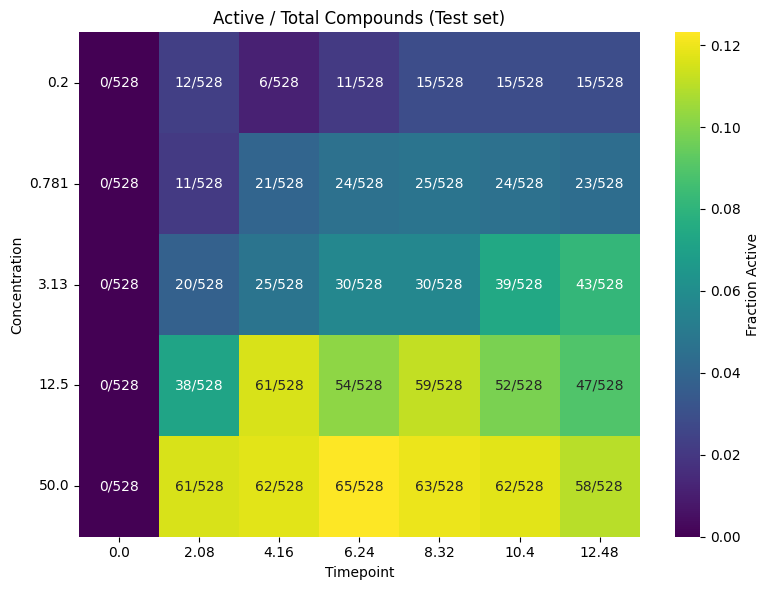

/tmp/ipykernel_943311/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


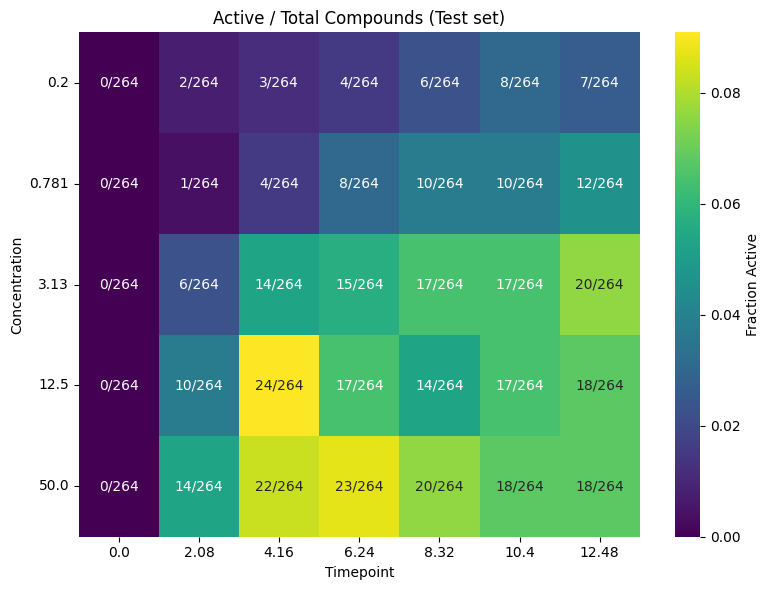

In [12]:
custom_bins = {
    -1: 20,                       # negatives
     0: 20,  # tests
     1: 20,                     # positives
}

def correct_plate_batch_effect_DR(df: pd.DataFrame) -> pd.DataFrame:
      """                                                                                   
      Plate-level batch correction for DR dataset using inactive test compounds
      as the reference baseline (since no controls on the same plates).                     
      Preserves OD scale by dividing by plate median and multiplying by global median.      
      """                                                                                   
      inactive = df[df['is_Active'] == 0]                                                   
                                                                                            
      # Plate-level medians of inactive compounds                                           
      plate_medians = (
          inactive                                                                          
          .groupby(['Plate_ID', 'Timepoint', 'Concentration'])['OD']
          .median()                                                                         
          .reset_index(name='plate_med')
      )                                                                                     
                  
      # Global medians (across plates) of inactive compounds                                
      global_medians = (
          inactive                                                                          
          .groupby(['Timepoint', 'Concentration'])['OD']
          .median()
          .reset_index(name='global_med')
      )
                                                                                            
      df_norm = df.merge(plate_medians, on=['Plate_ID', 'Timepoint', 'Concentration'],
  how='left')                                                                               
      df_norm = df_norm.merge(global_medians, on=['Timepoint', 'Concentration'], how='left')
                                                                                            
      denom = df_norm['plate_med'].to_numpy()
                                                                                            
      df_norm['OD'] = np.where(                                                             
          (denom > 0) & np.isfinite(denom),
          df_norm['OD'] / df_norm['plate_med'] * df_norm['global_med'],                     
          df_norm['OD']  # keep original if no reference available                          
      )                                                                                     
                                                                                            
      df_norm.drop(columns=['plate_med', 'global_med'], inplace=True)                       
      return df_norm

df_Enamine_DR_growthCurves = label_inactives_actives(df_Enamine_DR_growthCurves,mad_multiplier=2)

df_Enamine_DR_plate_batch_effect_DR = correct_plate_batch_effect_DR(df_Enamine_DR_growthCurves)

df_Enamine_DR_plate_batch_effect_DR = label_inactives_actives(df_Enamine_DR_plate_batch_effect_DR,mad_multiplier=2)

plot_activity_ratio_heatmap(df_Enamine_DR_plate_batch_effect_DR)

def normalize_wells_EnamineDR(df_long):

     #Inactive compounds
    inactive = df_long[df_long['is_Active'] == 0]

    #Per-spot median (Well, Timepoint)
    well_medians = (
        inactive
        .groupby(['Well','Timepoint','Concentration'])['OD']
        .median()
        .reset_index(name='well_meds')
    )


    #Global median per Timepoint
    global_medians = (
        inactive
        .groupby(['Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='global_meds')
    )

    df = df_long.merge(well_medians, on=['Well','Timepoint','Concentration'], how='left')
    df = df.merge(global_medians, on=['Timepoint','Concentration'], how='left')

    #batch‐corrected OD
    mask = df['Timepoint'] != 0
    df.loc[mask, 'OD'] = (
        df.loc[mask, 'OD'] 
        / df.loc[mask, 'well_meds'] 
       * df.loc[mask, 'global_meds']
    )
    
    df = df.drop(columns=['well_meds', 'global_meds'])

    return df, global_medians, well_medians


df_Enamine_DR_plate_well_batch_effect_DR,_,_ = normalize_wells_EnamineDR(df_Enamine_DR_plate_batch_effect_DR)

df_Enamine_DR_plate_well_batch_effect_DR_avg = (
    df_Enamine_DR_plate_well_batch_effect_DR
      .drop(columns='Replicate')                      
      .groupby(
          ['Plate_ID', 'Concentration',
           'Compound', 'Control_Label', 'Timepoint'],
          as_index=False
      )
      .agg(
          OD        = ('OD', 'mean'),
          Smiles    = ('Smiles', 'first'),
      )
)

df_Enamine_DR_plate_well_batch_effect_DR_avg=label_inactives_actives(df_Enamine_DR_plate_well_batch_effect_DR_avg,mad_multiplier=4)
plot_activity_ratio_heatmap(df_Enamine_DR_plate_well_batch_effect_DR_avg)

## Redo labels using actual negative controls

Active counts (DMSO-pooled threshold, k=4):


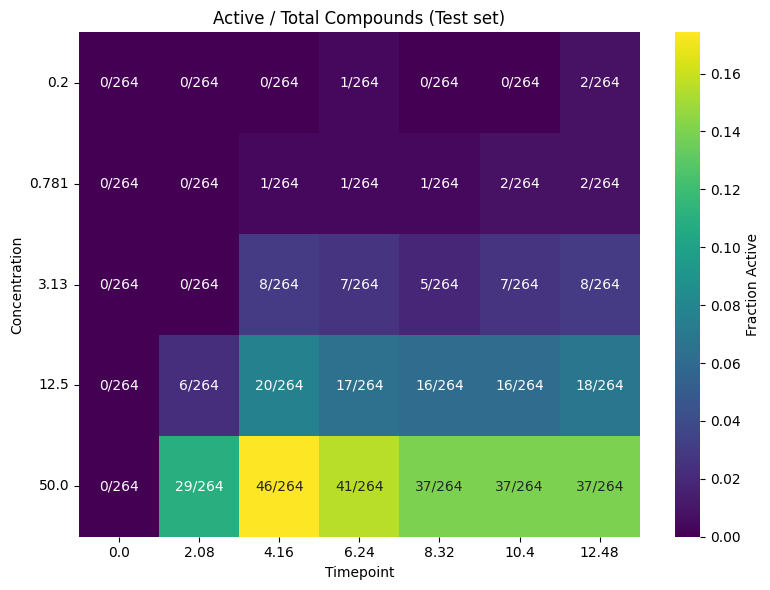


Active counts (DMSO-pooled):
Timepoint      0.00   2.08   4.16   6.24   8.32   10.40  12.48
Concentration                                                 
0.200              0      0      0      1      0      0      2
0.781              0      0      1      1      1      2      2
3.130              0      0      8      7      5      7      8
12.500             0      6     20     17     16     16     18
50.000             0     29     46     41     37     37     37

Total counts:
Timepoint      0.00   2.08   4.16   6.24   8.32   10.40  12.48
Concentration                                                 
0.200            264    264    264    264    264    264    264
0.781            264    264    264    264    264    264    264
3.130            264    264    264    264    264    264    264
12.500           264    264    264    264    264    264    264
50.000           264    264    264    264    264    264    264

Active fraction:
Timepoint      0.00   2.08   4.16   6.24   8.32   10.40

In [13]:
# Apply DMSO-pooled absolute threshold for final labels

# Compute per-timepoint DMSO threshold (pooled across concentrations)
_k_final = 4
_dmso_thresh_final = (
    df_cntrl[df_cntrl['Control_Label'] == -1]
    .groupby('Timepoint')['OD']
    .agg(
        n='size',
        median='median',
        mad=lambda x: 1.4826 * np.median(np.abs(x - x.median())),
    )
    .reset_index()
)
_dmso_thresh_final['threshold'] = _dmso_thresh_final['median'] - _k_final * _dmso_thresh_final['mad']
_dmso_thresh_final = _dmso_thresh_final[_dmso_thresh_final['Timepoint'] > 0]

# Apply threshold to corrected+averaged DR data
df_dr_labeled = df_Enamine_DR_plate_well_batch_effect_DR_avg.merge(
    _dmso_thresh_final[['Timepoint', 'threshold']], on='Timepoint', how='left'
)
df_dr_labeled['is_Active'] = (
    (df_dr_labeled['OD'] < df_dr_labeled['threshold']) & (df_dr_labeled['Timepoint'] > 0)
).astype(int)
df_dr_labeled.loc[df_dr_labeled['Timepoint'] == 0, 'is_Active'] = 0
df_dr_labeled = df_dr_labeled.drop(columns=['threshold'])

print('Active counts (DMSO-pooled threshold, k=4):')
plot_activity_ratio_heatmap(df_dr_labeled)

_total = df_dr_labeled.groupby(['Concentration', 'Timepoint']).size().unstack()
_active = df_dr_labeled[df_dr_labeled['is_Active'] == 1].groupby(['Concentration', 'Timepoint']).size().unstack().reindex_like(_total).fillna(0).astype(int)
_frac = (_active / _total).round(3)

print("\nActive counts (DMSO-pooled):")
print(_active.to_string())
print("\nTotal counts:")
print(_total.to_string())
print("\nActive fraction:")
print(_frac.to_string())

/home/ethan2/GrowthNet/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/home/ethan2/GrowthNet/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ethan2/GrowthNet/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


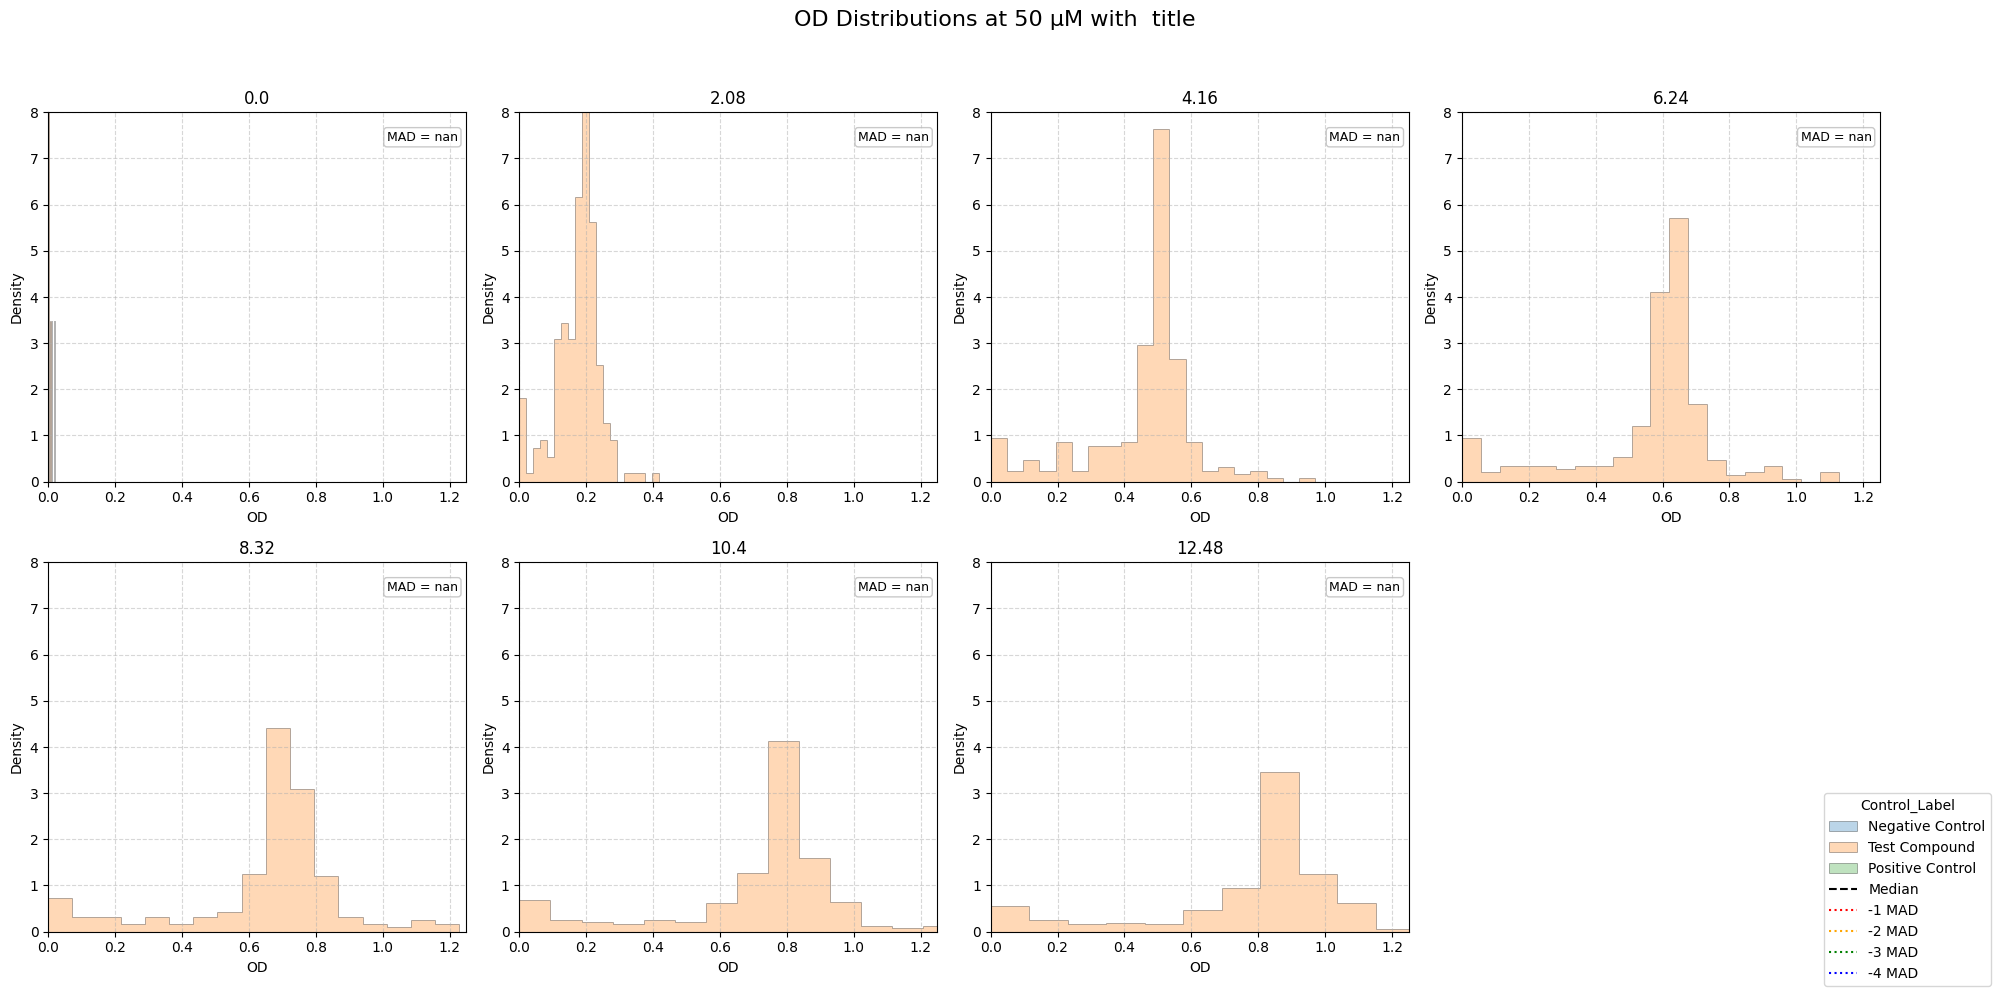

In [14]:
concentrations=[50]
for c in concentrations:
    plot_hist_od_distributions_long_neg_ctrl_threshold(
       ' title',
        correct_uncorrect='Plate + iterative well correction',
        dataset='df_Enamine_t6_t12',
        df_long=df_dr_labeled,
        concentration=c,
        bins=custom_bins, 
        max_x=1.25,
        max_density=8,
        save_path=False)

# Enamine t6 t12 processing

## Plate Correction

In [15]:
df_Enamine_plate_correction = correct_plate_batch_effect_dmso(df_Enamine.copy())


## Iterative well correction + labelling

Active-vs-inactive labels and the well-correction factor are interdependent: the
inactive subset defines the per-spot reference, but the threshold itself depends on
the corrected OD. The iterator alternates between (re)labelling and recomputing
well-correction factors on the *plate-corrected baseline* (factors are not
compounded across rounds), and stops when the fraction of label flips between
rounds drops below `tol`.

--- Initial labels (before any well correction) ---


/tmp/ipykernel_943311/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


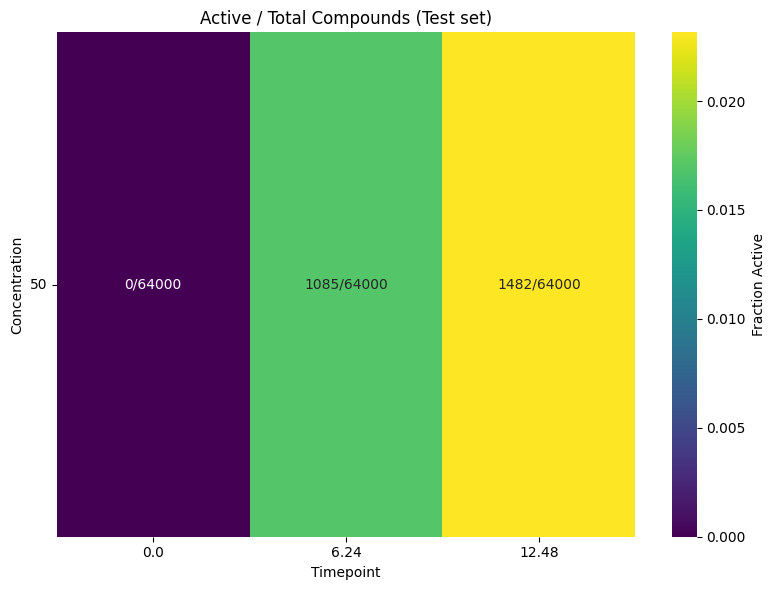

iter 1: flips=1192  (0.6208% of 192000 test rows)
--- Active labels after iter 1 ---


/tmp/ipykernel_943311/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


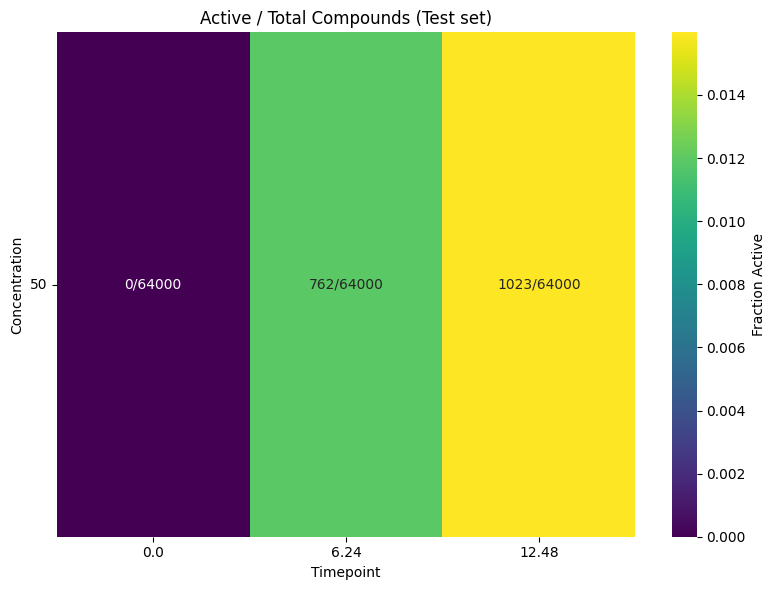

iter 2: flips=16  (0.0083% of 192000 test rows)
--- Active labels after iter 2 ---


/tmp/ipykernel_943311/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


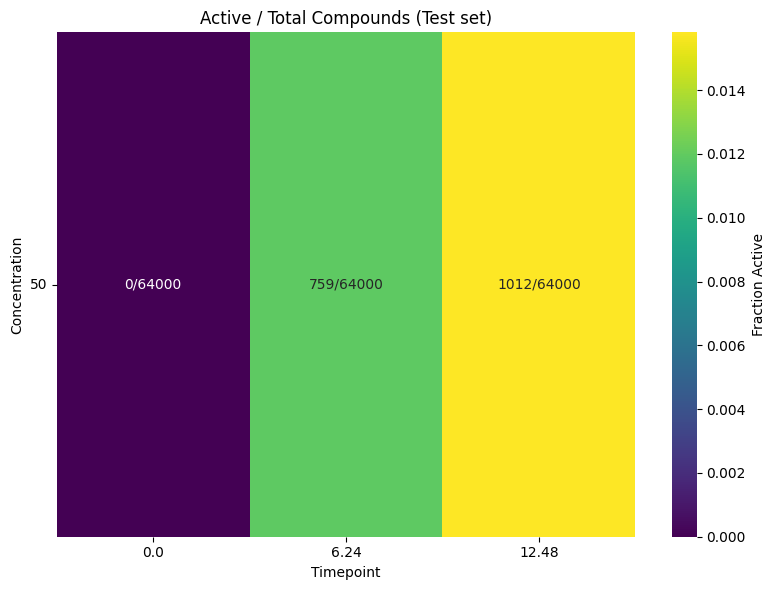

Converged at iter 2 (flip fraction < 0%).


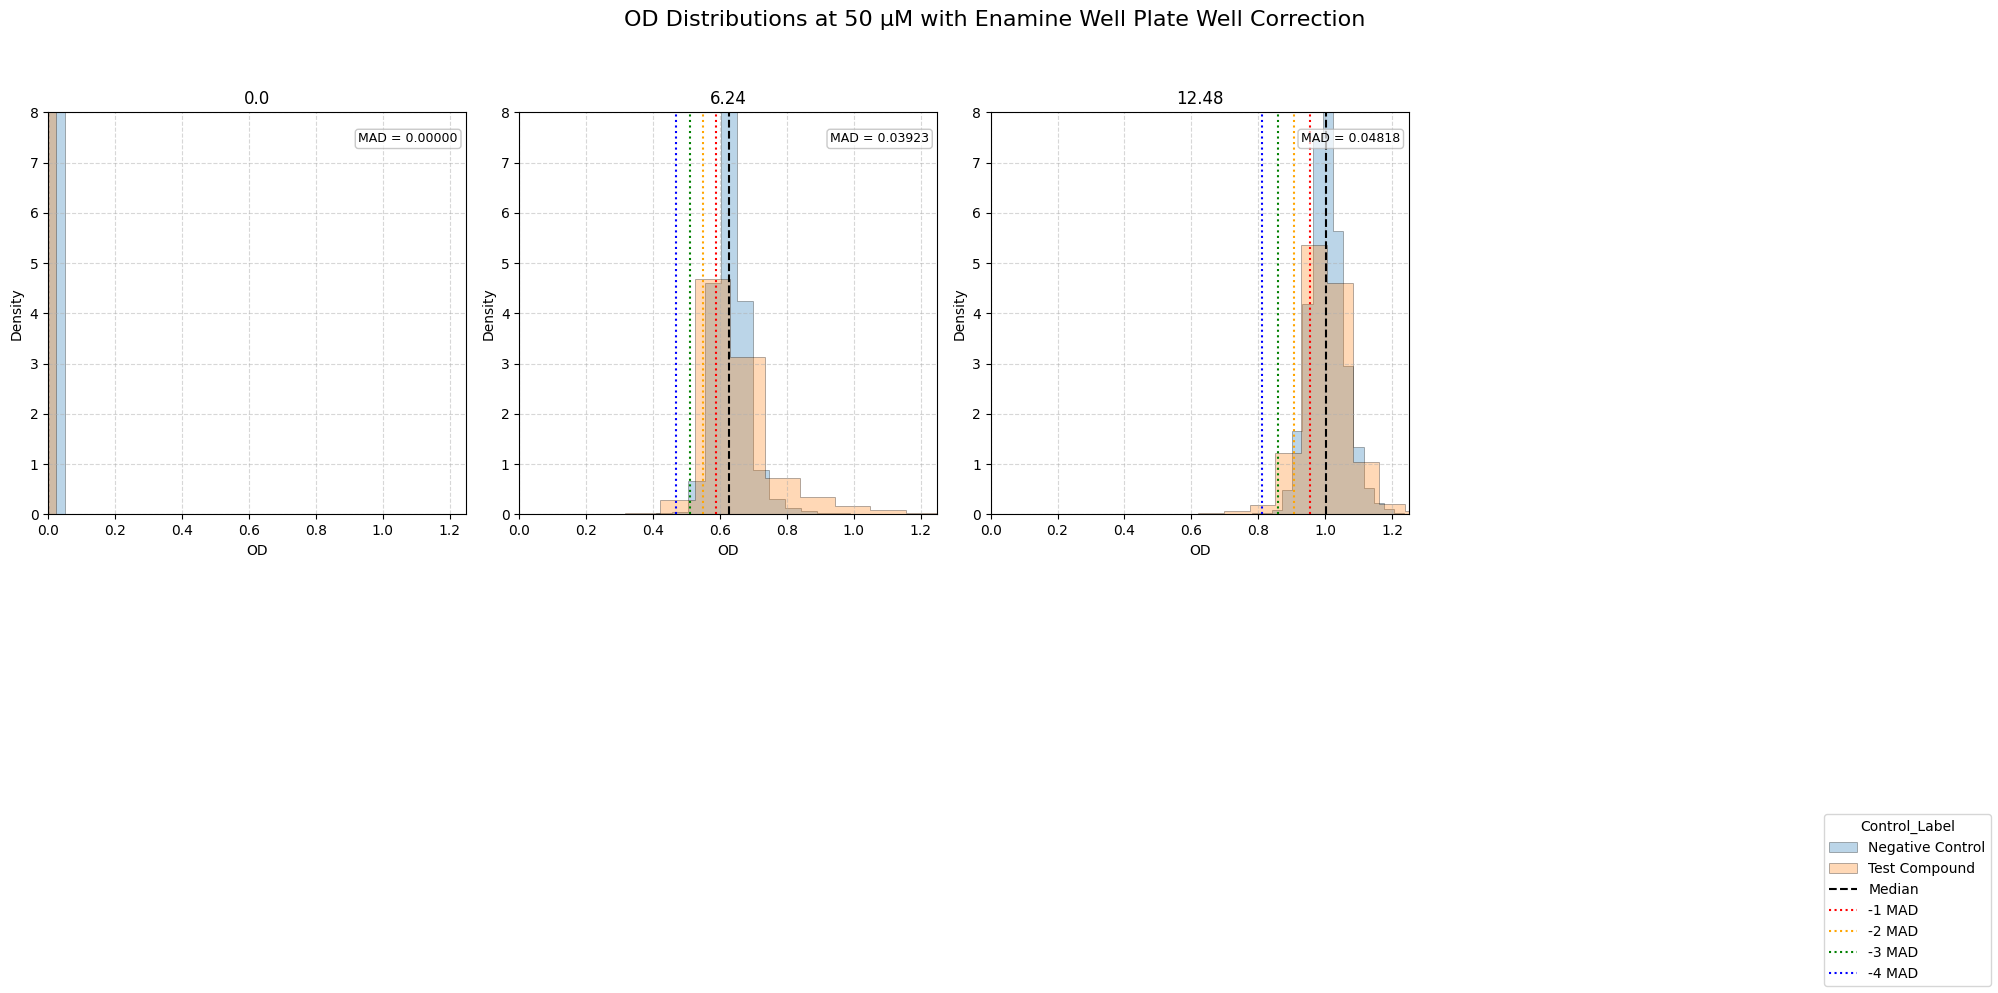

In [16]:
df_Enamine_plate_well_corrected, flip_history = iterate_label_and_well_correct(
    df_Enamine_plate_correction,
    mad_multiplier=4,
    max_iters=10,
    tol=0.001,
    plot_each_iter=True,
)

custom_bins = {
    -1: 20,                       # negatives
     0: 20,  # tests
     1: 20,                     # positives
}

title='Enamine Well Plate Well Correction'
concentrations=[50]
for c in concentrations:
    plot_hist_od_distributions_long_neg_ctrl_threshold(
        title,
        correct_uncorrect='correction_1',
        dataset='df_Enamine_t6_t12',
        df_long=df_Enamine_plate_well_corrected,
        concentration=c,
        bins=custom_bins, 
        max_x=1.25,
        max_density=8,
        plot_pos_ctrls=False,
        save_path=False
    )

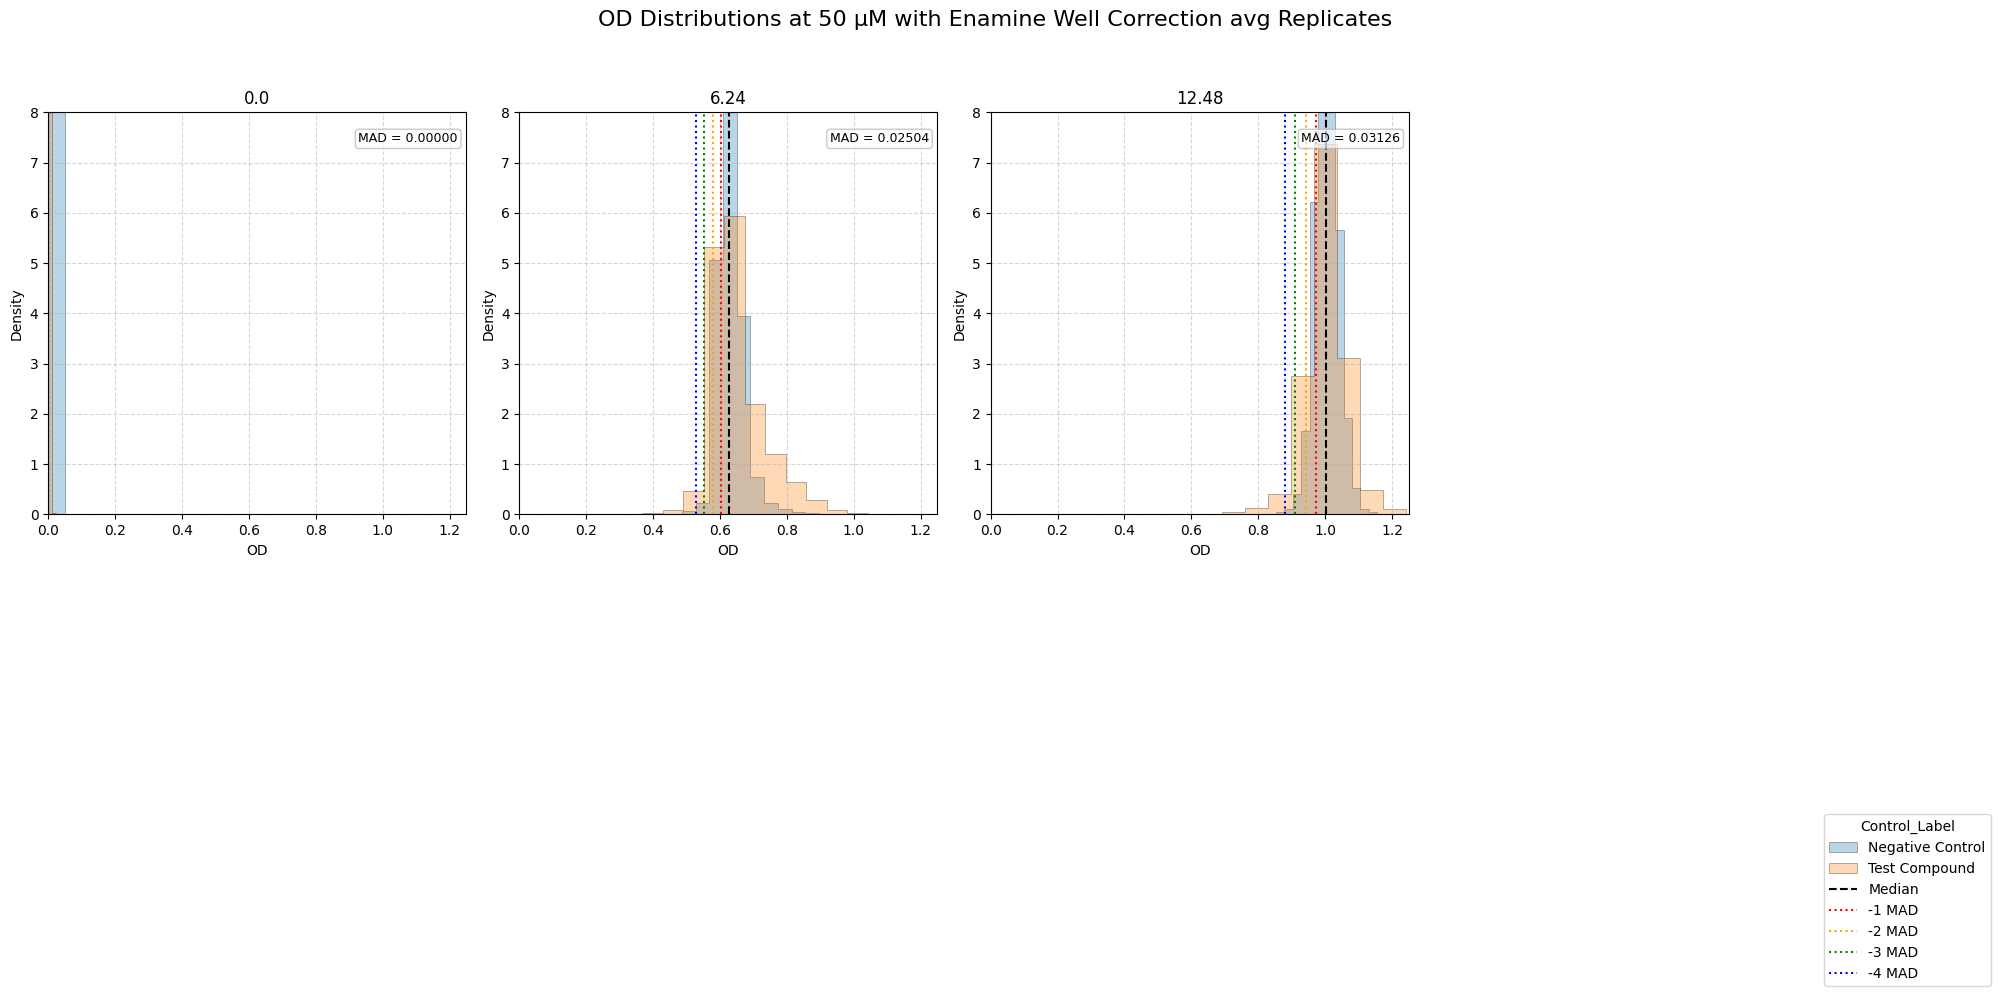

In [17]:
df_test_avg = (
      df_Enamine_plate_well_corrected[df_Enamine_plate_well_corrected['Control_Label'] == 0]                                          
        .groupby(['Plate_ID', 'Concentration', 'Compound',
  'Timepoint'], as_index=False)                                     
        .agg(     
            Control_Label = ('Control_Label', 'first'),
            OD            = ('OD', 'mean'),                         
            Smiles        = ('Smiles', 'first'),
        )                                                           
  ) 

# Controls: one row per (Plate, Well, Timepoint) — collapses replicates WITHIN a well
  # Keeping Well preserves the ~40 DMSO wells per plate so MAD is well-defined.  
  #                                                    
df_controls_avg = (
    df_Enamine_plate_well_corrected[df_Enamine_plate_well_corrected['Control_Label'] != 0]                                          
    .groupby(['Plate_ID', 'Well', 'Concentration', 'Compound',
'Timepoint'], as_index=False)                                     
    .agg(     
        Control_Label = ('Control_Label', 'first'),
        OD            = ('OD', 'mean'),                         
        Smiles        = ('Smiles', 'first'),
    )                                                           
)               

df_Enamine_plate_well_corrected_avg = pd.concat(                  
    [df_test_avg, df_controls_avg], ignore_index=True
) 


custom_bins = {
    -1: 20,                       # negatives
     0: 20,  # tests
     1: 20,                     # positives
}

title='Enamine Well Correction avg Replicates'
concentrations=[50]
for c in concentrations:
    plot_hist_od_distributions_long_neg_ctrl_threshold(
        title,
        correct_uncorrect='correction_1',
        dataset='df_Enamine_t6_t12',
        df_long=df_Enamine_plate_well_corrected_avg,
        concentration=c,
        bins=custom_bins, 
        max_x=1.25,
        max_density=8,
        plot_pos_ctrls=False,
        save_path=False
    )

/tmp/ipykernel_943311/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


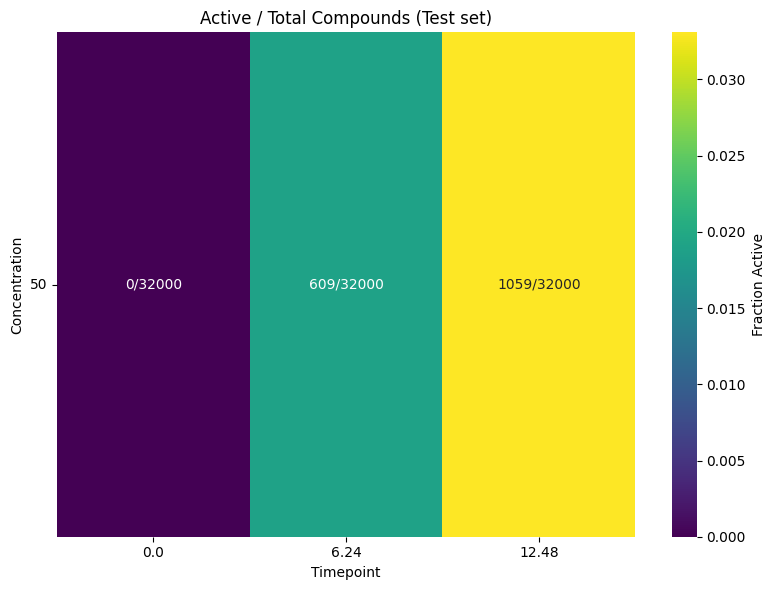

In [18]:
df_Enamine_plate_well_corrected_avg = label_inactives_actives(df_Enamine_plate_well_corrected_avg, mad_multiplier=4)
plot_activity_ratio_heatmap(df_Enamine_plate_well_corrected_avg[df_Enamine_plate_well_corrected_avg['Control_Label'] == 0])